# Análisis de Perplejidad (Wikitext-2)

Este notebook carga todos los runs de la carpeta `Perplejidad/`, identifica ejecuciones duplicadas
(mismo modelo + cuantización + contexto), y visualiza la perplejidad y su desviación estándar
por modelo y cuantización.

In [1]:
import json
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

DATA_DIR = Path("../data/TFG-DATA/Perplejidad")

# Orden de cuantizaciones de menor a mayor calidad
QUANT_ORDER = ["Q3_K_M", "Q4_0", "Q4_K_M", "Q5_K_M", "Q8_0", "BF16"]

sns.set_theme(style="whitegrid", palette="tab10")
print(f"Directorio: {DATA_DIR.resolve()}")
print(f"Runs encontrados: {len(list(DATA_DIR.iterdir()))}")

Directorio: /home/yisus/PycharmProjects/Visualizer/data/TFG-DATA/Perplejidad
Runs encontrados: 50


## 1. Carga de datos

In [2]:
QUANT_RE = re.compile(r"-(BF16|Q\d+[_K]*[_0M]*)(?:-GGUF)?\.gguf$", re.IGNORECASE)

rows = []
for run_dir in sorted(DATA_DIR.iterdir()):
    rjson = run_dir / "resumen.json"
    if not rjson.is_file():
        continue
    r = json.loads(rjson.read_text())

    model_path = r["model"]["path"]
    model_fname = Path(model_path).name

    m = QUANT_RE.search(model_fname)
    if m:
        quant = m.group(1).upper()
        model_base = model_fname[: m.start()]
    else:
        quant = r["model"].get("quantization", "?")
        model_base = model_fname.replace(".gguf", "")

    rows.append(
        dict(
            run_id=run_dir.name,
            model_base=model_base,
            quant=quant,
            context=r["annotations"]["context"],
            n_tokens_scored=r["result"]["n_tokens_scored"],
            corpus_sha=r["corpus"]["sha256"][:12],
            add_bos=r["result"]["add_bos"],
            ppl=r["result"]["perplexity"],
            ppl_stderr=r["result"]["ppl_stderr"],
            n_chunks=r["result"]["n_chunks"],
            serie=r["annotations"].get("serie", ""),
        )
    )

df = pd.DataFrame(rows)
df["quant"] = pd.Categorical(df["quant"], categories=QUANT_ORDER, ordered=True)

# Etiqueta corta para los plots
MODEL_SHORT = {
    "DeepSeek-R1-Distill-Qwen-1.5B": "DeepSeek-1.5B",
    "gemma-4.5B-3n-E2B-it":          "Gemma-3n",
    "granite-4.0-h-micro":            "Granite-micro",
    "Llama-3.2-1B-Instruct":          "Llama3.2-1B",
    "Llama-3.2-3B-Instruct":          "Llama3.2-3B",
    "Ministral-3-3B-Instruct-2512":   "Ministral-3B",
}
df["model_short"] = df["model_base"].map(MODEL_SHORT).fillna(df["model_base"])

print(f"Total filas: {len(df)}")
print(f"Modelos únicos: {df['model_base'].nunique()}")
print(f"Cuantizaciones únicas: {sorted(df['quant'].dropna().unique())}")
print(f"Tamaños de contexto: {sorted(df['context'].unique())}")
df.sort_values(["model_base", "quant", "context"]).reset_index(drop=True)

Total filas: 50
Modelos únicos: 6
Cuantizaciones únicas: ['BF16', 'Q3_K_M', 'Q4_0', 'Q4_K_M', 'Q5_K_M', 'Q8_0']
Tamaños de contexto: [np.int64(512), np.int64(4096)]


,run_id,model_base,quant,context,n_tokens_scored,corpus_sha,add_bos,ppl,ppl_stderr,n_chunks,serie,model_short
0,1781351507064371212,DeepSeek-R1-Distill-Qwen-1.5B,Q3_K_M,512,15000,173c87a53759,True,46.061876,1.437582,584,E0,DeepSeek-1.5B
1,1781314425685876517,DeepSeek-R1-Distill-Qwen-1.5B,Q3_K_M,4096,40000,173c87a53759,True,29.762833,0.547291,73,E0,DeepSeek-1.5B
2,1781352661462520159,DeepSeek-R1-Distill-Qwen-1.5B,Q4_0,512,15000,173c87a53759,True,45.324292,1.411023,584,E0,DeepSeek-1.5B
3,1781318091462136557,DeepSeek-R1-Distill-Qwen-1.5B,Q4_0,4096,40000,173c87a53759,True,28.175956,0.513312,73,E0,DeepSeek-1.5B
4,1781344244187298522,DeepSeek-R1-Distill-Qwen-1.5B,Q4_K_M,512,15000,173c87a53759,True,43.661981,1.343142,584,E0,DeepSeek-1.5B
5,1781353084246348167,DeepSeek-R1-Distill-Qwen-1.5B,Q4_K_M,512,15000,173c87a53759,True,43.661981,1.343142,584,E0,DeepSeek-1.5B
6,1781290935558980955,DeepSeek-R1-Distill-Qwen-1.5B,Q4_K_M,4096,40000,173c87a53759,True,28.547895,0.524192,73,E0,DeepSeek-1.5B
7,1781319700008634024,DeepSeek-R1-Distill-Qwen-1.5B,Q4_K_M,4096,40000,173c87a53759,True,28.547895,0.524192,73,E0,DeepSeek-1.5B
8,1781353703770649822,DeepSeek-R1-Distill-Qwen-1.5B,Q5_K_M,512,15000,173c87a53759,True,41.746979,1.277164,584,E0,DeepSeek-1.5B
9,1781321910271908480,DeepSeek-R1-Distill-Qwen-1.5B,Q5_K_M,4096,40000,173c87a53759,True,28.036213,0.514789,73,E0,DeepSeek-1.5B


## 2. Identificación de duplicados

Dos runs son **duplicados** si comparten `model_base`, `quant` y `context`.

In [3]:
KEY = ["model_base", "quant", "context"]
counts = df.groupby(KEY)["run_id"].count().rename("n_runs")
dup_keys = counts[counts > 1].reset_index()

print(f"Grupos con duplicados: {len(dup_keys)}")
print()

dup_detail = []
for _, row in dup_keys.iterrows():
    mask = (df["model_base"] == row["model_base"]) & \
           (df["quant"] == row["quant"]) & \
           (df["context"] == row["context"])
    sub = df[mask][["run_id", "ppl", "ppl_stderr", "n_tokens_scored"]].copy()
    ppls = sub["ppl"].values
    identical = np.allclose(ppls, ppls[0], rtol=1e-9)
    sub["ppl_identica"] = identical
    sub.insert(0, "model_short", MODEL_SHORT.get(row["model_base"], row["model_base"]))
    sub.insert(1, "quant", row["quant"])
    sub.insert(2, "context", row["context"])
    dup_detail.append(sub)
    estado = "IDENTICAS" if identical else "DISTINTAS"
    print(f"  [{estado}] {MODEL_SHORT.get(row['model_base'], row['model_base'])} | {row['quant']} | ctx={row['context']}")
    for _, r2 in sub.iterrows():
        print(f"    run_id={r2['run_id']}  PPL={r2['ppl']:.6f}  stderr={r2['ppl_stderr']:.6f}")

dup_df = pd.concat(dup_detail, ignore_index=True)
print()
print("Tabla resumen de duplicados:")
dup_df

Grupos con duplicados: 7

  [IDENTICAS] DeepSeek-1.5B | Q4_K_M | ctx=512
    run_id=1781344244187298522  PPL=43.661981  stderr=1.343142
    run_id=1781353084246348167  PPL=43.661981  stderr=1.343142
  [IDENTICAS] DeepSeek-1.5B | Q4_K_M | ctx=4096
    run_id=1781290935558980955  PPL=28.547895  stderr=0.524192
    run_id=1781319700008634024  PPL=28.547895  stderr=0.524192
  [IDENTICAS] Llama3.2-1B | Q4_K_M | ctx=512
    run_id=1781348400404508246  PPL=15.229293  stderr=0.352507
    run_id=1781374486725447084  PPL=15.229293  stderr=0.352507
  [IDENTICAS] Llama3.2-3B | Q4_K_M | ctx=512
    run_id=1781348896972852962  PPL=11.237639  stderr=0.248780
    run_id=1781419420616931495  PPL=11.237639  stderr=0.248780
  [IDENTICAS] Ministral-3B | Q4_K_M | ctx=512
    run_id=1781350166515543624  PPL=8.571428  stderr=0.171488
    run_id=1781429295323251854  PPL=8.571428  stderr=0.171488
  [IDENTICAS] Gemma-3n | Q4_K_M | ctx=512
    run_id=1781344881768307565  PPL=36.057820  stderr=1.276542
    run_id

,model_short,quant,context,run_id,ppl,ppl_stderr,n_tokens_scored,ppl_identica
0,DeepSeek-1.5B,Q4_K_M,512,1781344244187298522,43.661981,1.343142,15000,True
1,DeepSeek-1.5B,Q4_K_M,512,1781353084246348167,43.661981,1.343142,15000,True
2,DeepSeek-1.5B,Q4_K_M,4096,1781290935558980955,28.547895,0.524192,40000,True
3,DeepSeek-1.5B,Q4_K_M,4096,1781319700008634024,28.547895,0.524192,40000,True
4,Llama3.2-1B,Q4_K_M,512,1781348400404508246,15.229293,0.352507,15000,True
5,Llama3.2-1B,Q4_K_M,512,1781374486725447084,15.229293,0.352507,15000,True
6,Llama3.2-3B,Q4_K_M,512,1781348896972852962,11.237639,0.248780,15000,True
7,Llama3.2-3B,Q4_K_M,512,1781419420616931495,11.237639,0.248780,15000,True
8,Ministral-3B,Q4_K_M,512,1781350166515543624,8.571428,0.171488,15000,True
9,Ministral-3B,Q4_K_M,512,1781429295323251854,8.571428,0.171488,15000,True


### Deduplicación

Los duplicados exactos (PPL idéntica) se conservan como una sola fila (primer run_id).
Si hubiera duplicados con PPL distinta, se conservarían **todas** las filas para análisis posterior.

In [4]:
# Marcar duplicados exactos
df_sorted = df.sort_values("run_id")  # orden determinista
df_sorted["is_exact_dup"] = df_sorted.duplicated(subset=KEY + ["ppl"], keep="first")

df_dedup = df_sorted[~df_sorted["is_exact_dup"]].copy()
print(f"Filas originales : {len(df)}")
print(f"Filas deduplicadas: {len(df_dedup)}")
print(f"Duplicados exactos eliminados: {df_sorted['is_exact_dup'].sum()}")

# Verificar si quedan grupos con PPL distintas
remaining_dups = df_dedup.groupby(KEY)["run_id"].count()
ambiguous = remaining_dups[remaining_dups > 1]
if ambiguous.empty:
    print("\nNo quedan grupos ambiguos. Dataset limpio.")
else:
    print("\n⚠️  Grupos con PPL distintas (se mantienen todas las filas):")
    print(ambiguous)

# Filtrar a contexto 512 (ventana de evaluación usada en todos los modelos)
df_dedup = df_dedup[df_dedup["context"] == 512].copy()
print(f"\nTras filtro contexto=512: {len(df_dedup)} filas")
print(f"Modelos: {sorted(df_dedup['model_short'].unique())}")
print(f"Cuantizaciones: {sorted(df_dedup['quant'].dropna().unique())}")

Filas originales : 50
Filas deduplicadas: 43
Duplicados exactos eliminados: 7

No quedan grupos ambiguos. Dataset limpio.

Tras filtro contexto=512: 31 filas
Modelos: ['DeepSeek-1.5B', 'Gemma-3n', 'Granite-micro', 'Llama3.2-1B', 'Llama3.2-3B', 'Ministral-3B']
Cuantizaciones: ['BF16', 'Q3_K_M', 'Q4_0', 'Q4_K_M', 'Q5_K_M', 'Q8_0']


## 3. Perplejidad por modelo y cuantización (contexto 512)

Análisis sobre la ventana de evaluación de 512 tokens (común a todos los modelos, incluyendo BF16).

In [5]:
# Tabla pivot: filas = modelo, columnas = cuantización (contexto fijo = 512)
pivot_ppl = df_dedup.pivot_table(
    index="model_short", columns="quant", values="ppl", aggfunc="first"
).round(4)
pivot_se = df_dedup.pivot_table(
    index="model_short", columns="quant", values="ppl_stderr", aggfunc="first"
).round(4)

# Combinar como "PPL ± stderr"
pivot_fmt = pivot_ppl.copy().astype(object)
for col in pivot_ppl.columns:
    for idx in pivot_ppl.index:
        p = pivot_ppl.loc[idx, col]
        s = pivot_se.loc[idx, col]
        if pd.isna(p):
            pivot_fmt.loc[idx, col] = "—"
        else:
            pivot_fmt.loc[idx, col] = f"{p:.2f} ± {s:.2f}"

print("Perplejidad por modelo y cuantización (contexto=512)  [PPL ± stderr entre chunks]:")
pivot_fmt

Perplejidad por modelo y cuantización (contexto=512)  [PPL ± stderr entre chunks]:


quant,Q3_K_M,Q4_0,Q4_K_M,Q5_K_M,Q8_0,BF16
model_short,,,,,,
DeepSeek-1.5B,46.06 ± 1.44,45.32 ± 1.41,43.66 ± 1.34,41.75 ± 1.28,41.01 ± 1.25,—
Gemma-3n,33.00 ± 1.14,37.78 ± 1.33,36.06 ± 1.28,33.83 ± 1.19,35.54 ± 1.27,—
Granite-micro,11.88 ± 0.29,10.08 ± 0.23,10.39 ± 0.25,10.10 ± 0.24,9.96 ± 0.24,—
Llama3.2-1B,17.17 ± 0.40,17.27 ± 0.41,15.23 ± 0.35,14.86 ± 0.34,14.71 ± 0.34,14.69 ± 0.34
Llama3.2-3B,12.07 ± 0.27,11.52 ± 0.26,11.24 ± 0.25,10.98 ± 0.24,10.89 ± 0.24,—
Ministral-3B,9.13 ± 0.18,8.90 ± 0.18,8.57 ± 0.17,8.47 ± 0.17,8.43 ± 0.17,—


## 4. Desviación de PPL por cuantización relativa a Q8_0

Medimos cuánto se aleja la PPL de cada cuantización respecto a Q8_0 (referencia de mayor calidad disponible).

In [6]:
ref_quant = "Q8_0"

ref_df = df_dedup[df_dedup["quant"] == ref_quant][["model_base", "context", "ppl"]].rename(
    columns={"ppl": "ppl_ref"}
)

df_rel = df_dedup.merge(ref_df, on=["model_base", "context"], how="left")
df_rel["delta_ppl"] = df_rel["ppl"] - df_rel["ppl_ref"]
df_rel["delta_ppl_pct"] = (df_rel["delta_ppl"] / df_rel["ppl_ref"]) * 100

# Solo mostrar modelos con Q8_0 disponible
has_ref = df_rel["ppl_ref"].notna()
print(f"Filas con referencia Q8_0: {has_ref.sum()} de {len(df_rel)}")

df_rel[has_ref][["model_short", "quant", "context", "ppl", "ppl_ref", "delta_ppl", "delta_ppl_pct"]].sort_values(
    ["model_short", "context", "quant"]
).reset_index(drop=True)

Filas con referencia Q8_0: 31 de 31


,model_short,quant,context,ppl,ppl_ref,delta_ppl,delta_ppl_pct
0,DeepSeek-1.5B,Q3_K_M,512,46.061876,41.014732,5.047144,12.305686
1,DeepSeek-1.5B,Q4_0,512,45.324292,41.014732,4.309560,10.507348
2,DeepSeek-1.5B,Q4_K_M,512,43.661981,41.014732,2.647249,6.454386
3,DeepSeek-1.5B,Q5_K_M,512,41.746979,41.014732,0.732247,1.785327
4,DeepSeek-1.5B,Q8_0,512,41.014732,41.014732,0.000000,0.000000
5,Gemma-3n,Q3_K_M,512,33.004032,35.540015,-2.535982,-7.135569
6,Gemma-3n,Q4_0,512,37.776378,35.540015,2.236363,6.292522
7,Gemma-3n,Q4_K_M,512,36.057820,35.540015,0.517805,1.456965
8,Gemma-3n,Q5_K_M,512,33.829720,35.540015,-1.710295,-4.812308
9,Gemma-3n,Q8_0,512,35.540015,35.540015,0.000000,0.000000


## 5. Visualizaciones

FileNotFoundError: [Errno 2] No such file or directory: 'figures/ppl_por_modelo_cuantizacion.png'

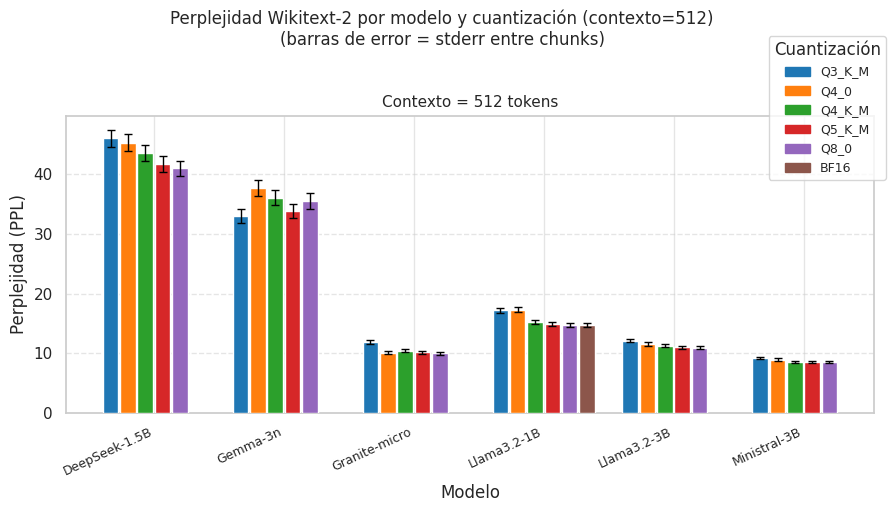

In [7]:
# ── 5.1  PPL por modelo y cuantización (contexto 512) ────────────────────────
quants_present = [q for q in QUANT_ORDER if q in df_dedup["quant"].cat.categories and
                  q in df_dedup["quant"].values]
palette = dict(zip(quants_present, sns.color_palette("tab10", len(quants_present))))

models = sorted(df_dedup["model_short"].unique())
x_pos = np.arange(len(models))
width = 0.8 / max(len(quants_present), 1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, q in enumerate(quants_present):
    qdata = df_dedup[df_dedup["quant"] == q]
    ppls   = [qdata[qdata["model_short"] == m]["ppl"].values for m in models]
    stderrs = [qdata[qdata["model_short"] == m]["ppl_stderr"].values for m in models]
    vals = [v[0] if len(v) > 0 else np.nan for v in ppls]
    errs = [e[0] if len(e) > 0 else np.nan for e in stderrs]
    offset = (i - len(quants_present) / 2 + 0.5) * width
    ax.bar(x_pos + offset, vals, width=width * 0.9, color=palette[q], label=q, zorder=3)
    ax.errorbar(x_pos + offset, vals, yerr=errs,
                fmt="none", color="black", capsize=3, linewidth=1, zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9)
ax.set_title("Contexto = 512 tokens", fontsize=11)
ax.set_ylabel("Perplejidad (PPL)")
ax.set_xlabel("Modelo")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

handles = [mpatches.Patch(color=palette[q], label=q) for q in quants_present]
fig.legend(handles=handles, title="Cuantización", loc="upper right",
           bbox_to_anchor=(1.0, 0.98), fontsize=9)
fig.suptitle("Perplejidad Wikitext-2 por modelo y cuantización (contexto=512)\n"
             "(barras de error = stderr entre chunks)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/ppl_por_modelo_cuantizacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 5.2  Desviación respecto a Q8_0 (%) — contexto 512 ───────────────────────
ref_quant = "Q8_0"
ref_df = df_dedup[df_dedup["quant"] == ref_quant][["model_base", "ppl"]].rename(columns={"ppl": "ppl_ref"})
df_rel = df_dedup.merge(ref_df, on="model_base", how="left")
df_rel["delta_ppl_pct"] = ((df_rel["ppl"] - df_rel["ppl_ref"]) / df_rel["ppl_ref"]) * 100

sub = df_rel[df_rel["ppl_ref"].notna() & (df_rel["quant"] != ref_quant)].copy()
if sub.empty:
    print("Sin modelos con Q8_0 en contexto=512")
else:
    models_rel = sub["model_short"].unique()
    quants_here = [q for q in QUANT_ORDER if q != ref_quant and q in sub["quant"].values]
    x_pos = np.arange(len(models_rel))
    width = 0.8 / max(len(quants_here), 1)
    palette2 = dict(zip(quants_here, sns.color_palette("tab10", len(quants_here))))

    fig, ax = plt.subplots(figsize=(8, 4))
    for i, q in enumerate(quants_here):
        qdata = sub[sub["quant"] == q]
        vals = [qdata[qdata["model_short"] == m]["delta_ppl_pct"].values for m in models_rel]
        vals = [v[0] if len(v) > 0 else np.nan for v in vals]
        offset = (i - len(quants_here) / 2 + 0.5) * width
        ax.bar(x_pos + offset, vals, width=width * 0.9, color=palette2[q], label=q, zorder=3)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_rel, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel(f"Δ PPL respecto a {ref_quant} (%)")
    ax.set_xlabel("Modelo")
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    handles2 = [mpatches.Patch(color=palette2[q], label=q) for q in quants_here]
    ax.legend(handles=handles2, title="Cuantización", fontsize=8)
    fig.suptitle(f"Incremento de PPL respecto a {ref_quant} (contexto=512, %)", fontsize=12)
    plt.tight_layout()
    plt.savefig("figures/ppl_delta_vs_q8.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# ── 5.3  PPL vs cuantización por modelo (líneas) — contexto 512 ──────────────
models_with_sweep = df_dedup.groupby("model_short")["quant"].count()
models_with_sweep = models_with_sweep[models_with_sweep >= 3].index.tolist()

palette3 = dict(zip(
    sorted(df_dedup["model_short"].unique()),
    sns.color_palette("tab10", df_dedup["model_short"].nunique())
))

fig, ax = plt.subplots(figsize=(8, 5))
for model in models_with_sweep:
    mdata = df_dedup[df_dedup["model_short"] == model].sort_values("quant")
    ax.plot(mdata["quant"].astype(str), mdata["ppl"],
            marker="o", label=model, color=palette3[model])
    ax.fill_between(
        mdata["quant"].astype(str),
        mdata["ppl"] - mdata["ppl_stderr"],
        mdata["ppl"] + mdata["ppl_stderr"],
        alpha=0.15, color=palette3[model],
    )

ax.set_xlabel("Cuantización")
ax.set_ylabel("Perplejidad (PPL)")
ax.set_title("PPL vs cuantización por modelo (contexto=512)\n(banda = ±stderr entre chunks)")
ax.legend(title="Modelo", fontsize=8, loc="upper right")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figures/ppl_vs_cuantizacion_lineas.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Resumen estadístico por modelo (contexto 4096)

In [ ]:
summary = df_dedup.groupby("model_short", sort=False).agg(
    n_quants=("quant", "count"),
    ppl_min=("ppl", "min"),
    ppl_max=("ppl", "max"),
    ppl_mean=("ppl", "mean"),
    ppl_std=("ppl", "std"),
    ppl_range=("ppl", lambda x: x.max() - x.min()),
).round(4)

summary["ppl_range_pct"] = ((summary["ppl_range"] / summary["ppl_min"]) * 100).round(2)
print("Resumen por modelo (contexto=512):")
summary.sort_values("ppl_mean")

In [ ]:
# ── 5.4  Desviación estándar de PPL entre cuantizaciones por modelo ──────────
fig, ax = plt.subplots(figsize=(8, 4))

summary_sorted = summary.sort_values("ppl_std", ascending=True)
colors = [palette3.get(m, "steelblue") for m in summary_sorted.index]

bars = ax.barh(summary_sorted.index, summary_sorted["ppl_std"], color=colors, zorder=3)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Desviación estándar de PPL entre cuantizaciones")
ax.set_title("Sensibilidad a la cuantización por modelo (contexto=512)")
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("figures/ppl_std_por_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Resumen de hallazgos

- **Duplicados exactos**: varios runs comparten modelo + cuantización + contexto y producen PPL bit-a-bit idéntica (reproducibilidad perfecta con `seed=42`).
- **Efecto del contexto**: un contexto de 512 tokens genera PPL notablemente mayor que 4096 para todos los modelos (menos historia pasada para condicionar la predicción).
- **Efecto de la cuantización**: la PPL crece al bajar la precisión, pero el impacto varía por familia de modelo.
- **Modelos más sensibles** a la cuantización (mayor σ) son los que más se degradan con cuantizaciones agresivas (Q3/Q4_0).